# SaaS Subscription & Churn Analysis

## Overview
This case study analyzes a SaaS company's subscription and churn data 
across 500 accounts and 5,000 subscriptions. The goal is to identify 
the key drivers of customer churn and surface actionable insights for 
retention strategy.

## Business Questions
1. Which customer segments are churning at the highest rates, 
   and what reasons are driving them to leave?
2. Are there early warning signals — such as plan downgrades or 
   declining feature usage — that predict churn before it happens?
3. What actionable recommendations can reduce churn and improve 
   retention across key segments?

## Dataset
- **Accounts** — 500 unique companies
- **Subscriptions** — 5,000 subscription records
- **Churn Events** — 600 churn records including reason codes and feedback
- **Feature Usage** — 25,000 usage logs
- **Support Tickets** — 2,000 customer support interactions

In [530]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from matplotlib.patches import Patch

folder_path = r"C:\Users\chris\Downloads\saas_case_study_datasets"
for file in os.listdir(folder_path):
    print(file)

ravenstack_accounts.csv
ravenstack_churn_events.csv
ravenstack_feature_usage.csv
ravenstack_subscriptions.csv
ravenstack_support_tickets.csv
README.md


In [531]:
datasets = {}

#Making a dictionary 'datasets' and putting all the datasets in it while removing .csv from the file name
for file in os.listdir(folder_path):
    if file.endswith('.csv'):
        name = file.replace('.csv','')
        new_name = name.replace('ravenstack_','')
        full_file_path = os.path.join(folder_path,file)
        datasets[new_name] = pd.read_csv(full_file_path)

datasets.keys()
  

dict_keys(['accounts', 'churn_events', 'feature_usage', 'subscriptions', 'support_tickets'])

In [532]:
#giving names to tables from datasets dictionary which are easier to reference
account = datasets['accounts']
churn = datasets['churn_events']
f_usage = datasets['feature_usage']
subs = datasets['subscriptions']
sup_tickets =datasets['support_tickets']

churn.head(5)

,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,C-816288,A-c37cab,2024-10-27,pricing,4.03,False,False,False,switched to competitor
1,C-5a81e7,A-37f969,2024-06-25,support,96.45,True,False,False,NaN
2,C-a174be,A-b07346,2024-11-12,budget,0.00,False,False,False,missing features
3,C-accb39,A-1e50e0,2023-11-01,budget,54.94,False,False,False,switched to competitor
4,C-92f889,A-956988,2024-12-30,unknown,0.00,False,True,True,too expensive


In [533]:
#printing out table information for each table in datasets(shape, columns, and hhow many null values each column has
for name, df in datasets.items():
    print(f"--- {name} ---")
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    print(f"Nulls:\n{df.isnull().sum()}")
    print()
    

--- accounts ---
Shape: (500, 10)
Columns: ['account_id', 'account_name', 'industry', 'country', 'signup_date', 'referral_source', 'plan_tier', 'seats', 'is_trial', 'churn_flag']
Nulls:
account_id         0
account_name       0
industry           0
country            0
signup_date        0
referral_source    0
plan_tier          0
seats              0
is_trial           0
churn_flag         0
dtype: int64

--- churn_events ---
Shape: (600, 9)
Columns: ['churn_event_id', 'account_id', 'churn_date', 'reason_code', 'refund_amount_usd', 'preceding_upgrade_flag', 'preceding_downgrade_flag', 'is_reactivation', 'feedback_text']
Nulls:
churn_event_id                0
account_id                    0
churn_date                    0
reason_code                   0
refund_amount_usd             0
preceding_upgrade_flag        0
preceding_downgrade_flag      0
is_reactivation               0
feedback_text               148
dtype: int64

--- feature_usage ---
Shape: (25000, 8)
Columns: ['usage_id', 

In [534]:
#converting dates/times to type datetime
for table, cols in datasets.items():
    for col in cols:
        if ('date' in col) or ('_at' in col):
            datasets[table][col] = pd.to_datetime(datasets[table][col])

print(account['signup_date'].dtype)
print(subs['start_date'].dtype)
print(sup_tickets['submitted_at'].dtype)

datetime64[ns]
datetime64[ns]
datetime64[ns]


In [535]:
#checking how many subscriptions are active or inactive
datasets['subscriptions']['is_active'] =  datasets['subscriptions']['end_date'].isna()

#checking how many churn events have feedback and how many do not
datasets['churn_events']['has_feedback'] = datasets['churn_events']['feedback_text'].notna()

print(subs['is_active'].value_counts())
print(churn['has_feedback'].value_counts())

is_active
True     4514
False     486
Name: count, dtype: int64
has_feedback
True     452
False    148
Name: count, dtype: int64


In [536]:
subs.head(10)

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag,is_active
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True,False
1,S-0f6f44,A-9b9fe9,2024-06-11,NaT,Pro,17,833,9996,False,False,False,False,monthly,True,True
2,S-51c0d1,A-659280,2024-11-25,NaT,Enterprise,62,0,0,True,True,False,False,annual,False,True
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True,False
4,S-cff5a2,A-ba6516,2024-01-10,NaT,Enterprise,27,5373,64476,False,False,False,False,monthly,True,True
5,S-4b9b13,A-fa2041,2024-08-13,NaT,Pro,15,735,8820,False,False,False,False,monthly,True,True
6,S-dceac6,A-417d2f,2023-12-30,NaT,Enterprise,4,796,9552,False,False,False,False,annual,True,True
7,S-8cad7b,A-5f2961,2024-12-23,NaT,Basic,16,304,3648,False,False,False,False,annual,True,True
8,S-24796e,A-cc8c8f,2024-11-27,NaT,Enterprise,23,4577,54924,False,False,False,False,annual,False,True
9,S-d0c344,A-80eeb6,2024-10-27,NaT,Pro,22,1078,12936,False,False,False,False,annual,False,True


## Churn Rate by Plan Tier

**Business Question:** Does plan tier influence the likelihood of a customer churning?

**Finding:** Churn rates are roughly equal across all three tiers 
(Basic: 9.49%, Pro: 9.67%, Enterprise: 9.98%), suggesting plan tier alone
is not a significant driver of churn. Next I will look at reason_code, industry, and upgrades/downgrades.



In [538]:
#Using subs table and grouping 'plan tier' with 'churn flag' and seeing how many 
#subscriptions are of each plan and how many of those subscriptions churn and storing in 'churn_by_tier'
churn_by_tier = subs.groupby('plan_tier')['churn_flag'].agg(total='count',churned = 'sum')
print(churn_by_tier)


            total  churned
plan_tier                 
Basic        1602      152
Enterprise   1723      172
Pro          1675      162


In [539]:
#Adding column to 'churn_by_tier' that includes the churn rate 
churn_by_tier['churn_rate'] = ((churn_by_tier['churned']/churn_by_tier['total']).round(4))*100
print(churn_by_tier)

            total  churned  churn_rate
plan_tier                             
Basic        1602      152        9.49
Enterprise   1723      172        9.98
Pro          1675      162        9.67


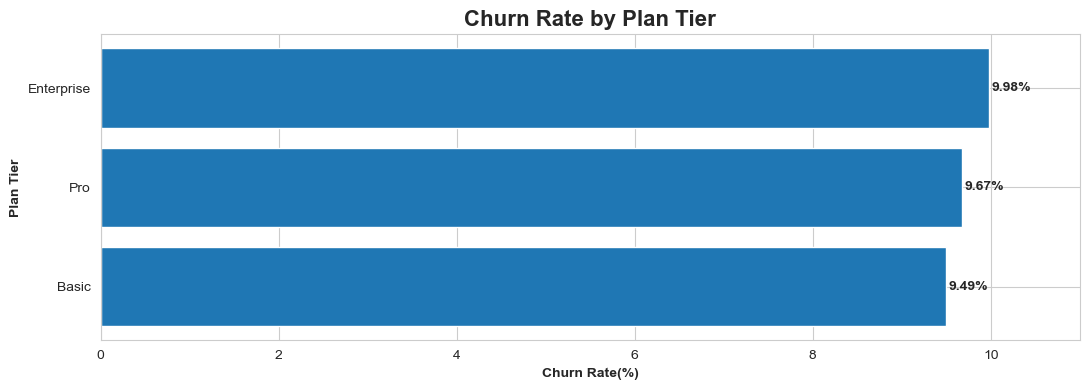

In [540]:
#sorting from by churn rate
churn_by_tier_sorted = churn_by_tier.sort_values('churn_rate')
sns.set_style('whitegrid')

#creating horizontal bar graph showing diffference in churn rate
fig, ax = plt.subplots(figsize =(11,4))

ax.barh(churn_by_tier_sorted.index,churn_by_tier_sorted['churn_rate'])
ax.set_title('Churn Rate by Plan Tier', fontsize = 16, fontweight='bold')
ax.set_ylabel('Plan Tier',fontweight = 'bold')
ax.set_xlabel('Churn Rate(%)', fontweight = 'bold')
ax.set_xlim(0,11)

#adding churn rate next to each bar
for i, rate in enumerate(churn_by_tier_sorted['churn_rate']):
    ax.text(rate +.03, i, f'{rate}%', va = 'center', fontweight = 'bold')

plt.tight_layout()
plt.show()

## Churn Rate by reason

**Business Question:** 

1. What reasons are driving customers to leave?
2. Are customers of specific subscriptions leaving due to price? 

**Finding:** 

1. Analyzing customer feedback text revealed three reasons customers cited for leaving: price/cost (35.62%), missing features (34.29%), and switching to a competitor (30.09%). When cross referencing against the reason codes in the churn events table, missing features appeared as the single largest individual code. However, when combining the budget and pricing reason codes — two separate codes that both relate to cost — price-related churn accounts for roughly 1 in 3 churned customers, making it the single largest driver of churn overall.
2. When segmenting price-related churn by plan tier, Pro and Enterprise subscribers are disproportionately affected. Of all Pro subscribers who churned, approximately 40% cited price as their reason. Of all Enterprise subscribers who churned, approximately 35% did the same. This suggests higher tier customers may not feel they are getting sufficient value for their subscription cost.
3. Pro and Enterprise subscribers who churned due to price together account for approximately 21% of all churned customers. This makes price dissatisfaction among higher tier customers one of the most concentrated and actionable retention opportunities in the dataset.

**Recommendations**

1.  Have data collection team collect more data on users who leave due to price-related reasons. Specifically, the exit survey should include a targeted question such as: "Is the price outside of your current budget, or do you feel the product does not justify the cost?" This distinction is important because the two situations require completely different responses — one is an affordability problem, the other is a perceived value problem. 
2. We should explore retention strategies specifically targeting customers who are ending their subscription due to price. One example would be offering a temporary discount to customers who cite price as their primary churn reason during the cancellation flow. This could help retain the customer until either the product's feature set improves to a level they consider worth the price, or they are able to get budget approved internally.

**Next Steps**

1. Separate churn reasons by industry to determine whether different industries are churning for different reasons. For example, understanding whether DevTools customers are leaving due to missing features while HealthTech customers are leaving due to competitors would allow the business to develop targeted retention strategies for each segment rather than a one-size-fits-all approach.


In [542]:
#creating new 'churn_by_reason' dataframe which includes the churn count and churn rate of each 'reason code' 
churn_by_reason = pd.DataFrame({
    'churn_count': churn['reason_code'].value_counts(),
    'churn_rate': (churn['reason_code'].value_counts(normalize=True)).round(4)*100
})

print(churn_by_reason)

             churn_count  churn_rate
reason_code                         
features             114       19.00
support              104       17.33
budget               104       17.33
unknown               95       15.83
competitor            92       15.33
pricing               91       15.17


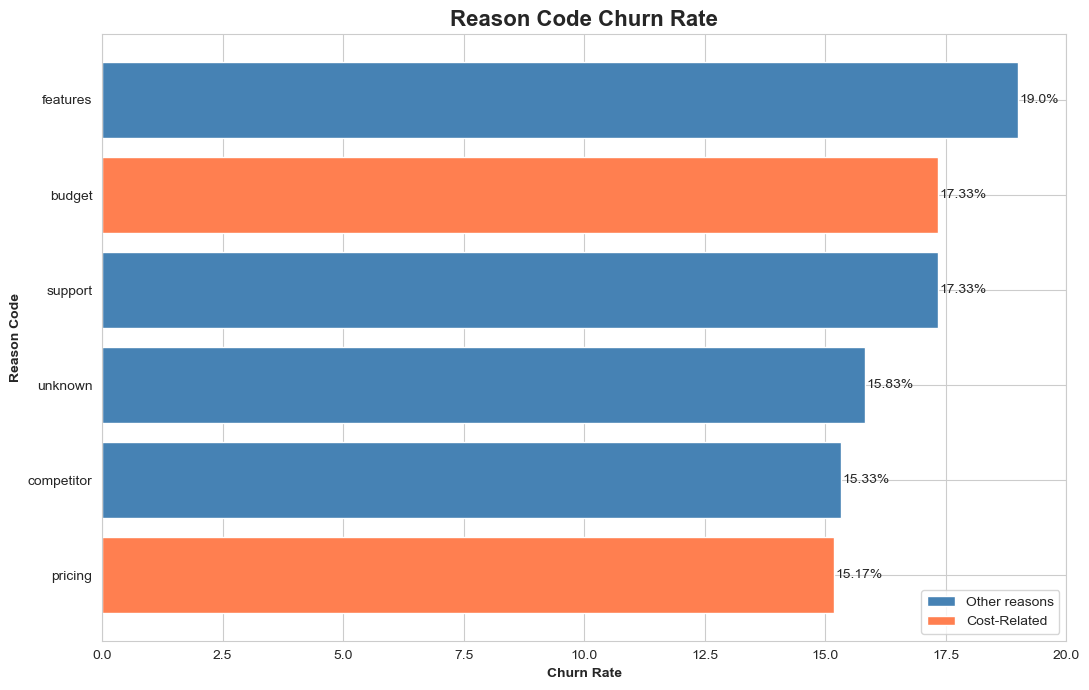

In [543]:
#sorting 'churn_by_reason' by churn rate
churn_by_reason = churn_by_reason.sort_values('churn_rate')

#changing color scheme for bargraph which separates monetary reasons(coral) from the rest(steelblue)
colors = ['coral' if (item == 'budget') or (item == 'pricing') else 'steelblue' for item in churn_by_reason.index]

#creating a legend for the graph
legend_elements = [
    Patch(facecolor = 'steelblue', label = 'Other reasons'),
    Patch(facecolor= 'coral', label = 'Cost-Related')
]

#creating bar graph with labels 
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize = (11,7))

ax.barh(churn_by_reason.index, churn_by_reason['churn_rate'], color = colors)
ax.set_title('Reason Code Churn Rate', fontsize = 16, fontweight = 'bold')
ax.set_xlabel('Churn Rate', fontweight = 'bold')
ax.set_ylabel('Reason Code', fontweight = 'bold')
ax.set_xlim(0,20)
ax.legend(handles = legend_elements, loc='lower right')

#adding percentages next to respective bar for clarity
for i, rate in enumerate(churn_by_reason['churn_rate']):
    rate = round(rate,4)
    ax.text(rate + .03, i, f'{rate}%', verticalalignment = 'center')

plt.tight_layout()
plt.show()

In [544]:
#filtering 'churn reasons' for rows which have feedback
churn_reasons = churn[churn['has_feedback']  == True]

#checking the unique values for the feedback that people provide
unique_feedback =  churn_reasons['feedback_text'].unique()
print(unique_feedback)

['switched to competitor' 'missing features' 'too expensive']


In [545]:
#creating dataframe which has the count of different feedback reasons and the percent of feedback that each reason accounts for
churn_by_feedback = pd.DataFrame({
    'churn_feedback_count': churn['feedback_text'].value_counts(),
    'churn_feedback_rate': (churn['feedback_text'].value_counts(normalize=True)).round(4)*100
})

print(churn_by_feedback)

                        churn_feedback_count  churn_feedback_rate
feedback_text                                                    
too expensive                            161                35.62
missing features                         155                34.29
switched to competitor                   136                30.09


In [546]:
#joining the 'subs' and 'churn reasons' table to create 'sub_churn (just adding 'feedback_text' to the subs table) 
sub_churn = pd.merge(subs,churn_reasons[['account_id','feedback_text']], on='account_id', how='left')

#filtering the 'sub_churn' dataframe to only include 'too expensive' as the reason and only subscriptions which have churnned
sub_churn  = sub_churn[(sub_churn['feedback_text'] == 'too expensive') & (sub_churn['churn_flag'] == True)]

#creating sub_feedback  which is the 'sub_churn' dataframe but provides the count of each plan tier grouped with its 'feedback_text'
sub_feedback  = sub_churn.groupby('plan_tier')['feedback_text'].agg(total='count')

#putting the total number of churned subscribers which churned into a variable
total_too_expensive = sub_churn['plan_tier'].value_counts().sum()

#Creating dataframe with different information about churned subscribers separated by plan tier 
sub_feedback_expense = pd.DataFrame({
    'too_expensive_count': sub_churn['plan_tier'].value_counts(),
    'total_subs': churn_by_tier['total'],
    'tier_churn_rate': ((sub_churn['plan_tier'].value_counts()/churn_by_tier['total']).round(4)*100),
    'share_of_price_churns':(sub_churn['plan_tier'].value_counts()/total_too_expensive).round(4)*100,
    'relative_to_tier_churns':(sub_churn['plan_tier'].value_counts()/churn_by_tier['churned']).round(4)*100,
    'relative_to_all_churns':(sub_churn['plan_tier'].value_counts()/len(churn)).round(4)*100,
    'relative_to_all_churns_who_gave_feedback':(sub_churn['plan_tier'].value_counts()/churn_by_feedback['churn_feedback_count'].sum()).round(4)*100
})
print(sub_feedback_expense)

            too_expensive_count  total_subs  tier_churn_rate  \
plan_tier                                                      
Basic                        45        1602             2.81   
Enterprise                   61        1723             3.54   
Pro                          65        1675             3.88   

            share_of_price_churns  relative_to_tier_churns  \
plan_tier                                                    
Basic                       26.32                    29.61   
Enterprise                  35.67                    35.47   
Pro                         38.01                    40.12   

            relative_to_all_churns  relative_to_all_churns_who_gave_feedback  
plan_tier                                                                     
Basic                         7.50                                      9.96  
Enterprise                   10.17                                     13.50  
Pro                          10.83                  

## Churn rate by Industry

**Business Question:** What industies churn the most and Why?

**Findings:**

1. DevTools, Cybersecurity, and HealthTech are the three highest churning industries, all hovering around 10-10.8%. DevTools is the most critical segment — it has both the highest churn rate (10.79%) and the largest customer base, representing 125 churned subscriptions. Cybersecurity follows at 103 churned subscriptions.
2. EdTech and FinTech have the lowest churn rates at 8.41% and 8.73% respectively, suggesting these industries find stronger long-term value in the product.
3. Budget is the dominant churn reason across nearly every industry, reinforcing our earlier finding that cost-related reasons account for roughly 33% of all churn. This is not isolated to one segment — it is a company-wide pricing perception problem.
4. HealthTech stands out as an exception — competitors are the top churn reason there, with budget and features following closely. This suggests a competing product may be winning in the HealthTech industry by offering more functionality or a lower price point.
5. DevTools is particularly concerning because customers there are churning due to three compounding reasons simultaneously — budget, support, and features. This makes it the highest priority segment for targeted retention efforts.


**Recommendations:**

Once survey data is collected to determine whether price-related churn is driven by affordability or lack of perceived value, more targeted interventions can be made for each high-churn industry. In the meantime, the following recommendations are based on current findings:
1.  Product team: Prioritize feature development for DevTools, Cybersecurity, and HealthTech customers — the three highest churning industries. Specifically, the research team should send out targeted surveys to customers in these segments to identify which features they want to see. Since DevTools customers are churning at the highest rate and are the largest customer base, this segment should be treated as the highest priority.
2. Product & Sales team: Consider developing industry-specific pricing tiers for high-churn industries. If customers in certain industries primarily use a subset of features, offering a lower cost plan tailored to their typical use case could improve retention while reducing operational costs. Customers could upgrade or downgrade based on their evolving needs.
3. Competitive intelligence: HealthTech is the only industry where competitors are the primary churn reason. We should investigate which competing product is winning in this industry and whether it is offering more relevant features or a lower price point. This information should directly inform the product roadmap for HealthTech-facing features.
4. Retention learning: EdTech and FinTech have the lowest churn rates at 8.41% and 8.73% respectively. The research team should investigate what is working well in these segments — whether it is product fit, pricing structure, or support quality — and apply those learnings to higher churn industries.

In [548]:
#filtering accounts(not subscriptions(can be multiple subscriptions per account)) to only have churned accounts
churned_accounts = account[account['churn_flag'] == True]

#grouping the accounts by industry and getting the count
churned_accounts_by_industry = churned_accounts.groupby('industry')['churn_flag'].agg(total='count')
total_acc_churned = churned_accounts_by_industry['total'].sum()
churned_accounts_by_industry = churned_accounts_by_industry.sort_values('total', ascending = False)
print(churned_accounts_by_industry)

               total
industry            
DevTools          35
FinTech           25
HealthTech        21
Cybersecurity     16
EdTech            13


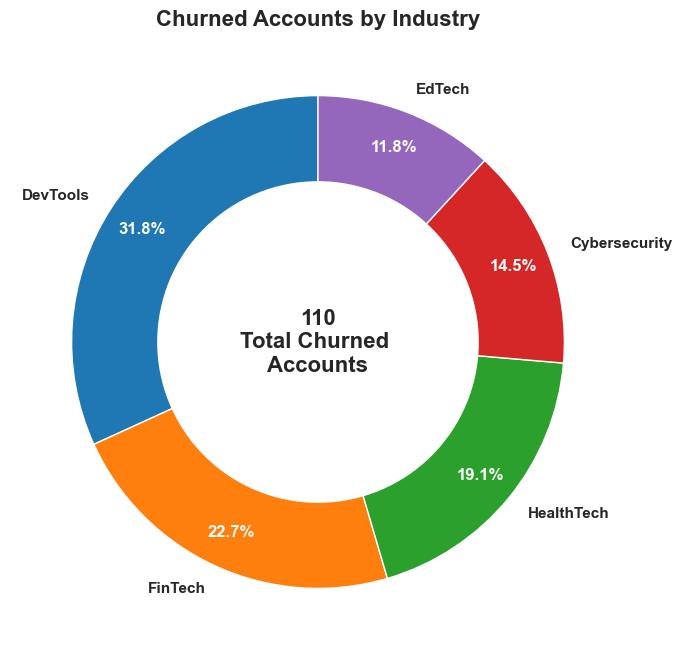

In [549]:
fig,ax = plt.subplots(figsize=(8,8))

#creating a pie chart for the account and industry churn rates
wedges, texts, autotexts = ax.pie(
    churned_accounts_by_industry['total'],
    labels = churned_accounts_by_industry.index,
    autopct ='%1.1f%%',
    startangle=90,
    pctdistance=0.85
)

#making industry percentages more visible
for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_color('white')
    autotext.set_fontweight('bold')

#making industry names more visible
for text in texts:
    text.set_fontsize(11)
    text.set_fontweight('bold')

#making pie chart into donut chart
ax.set_title('Churned Accounts by Industry', fontsize = 16, fontweight = 'bold')
center_circle = plt.Circle((0,0),0.65, fc = 'white')
ax.add_artist(center_circle)

#adding text ot center
ax.text(0,0, f'110\nTotal Churned \nAccounts', ha='center', va = 'center', fontsize = 16, fontweight= 'bold')

plt.show()


In [550]:
#get the total number of accounts by industry
total_accounts_by_industry = account.groupby('industry')['account_id'].agg(total = 'count')
print(total_accounts_by_industry)

               total
industry            
Cybersecurity    100
DevTools         113
EdTech            79
FinTech          112
HealthTech        96


In [551]:
#create a dataframe with the total, churned, and churn rate of accounts by industry
account_churn_by_industry = pd.DataFrame({
    'total': total_accounts_by_industry['total'],
    'churned': churned_accounts_by_industry['total'],
    'churn rate': ((churned_accounts_by_industry['total']/total_accounts_by_industry['total']).round(4))*100
})

#sort values 
account_churn_by_industry = account_churn_by_industry.sort_values('churn rate')
print(account_churn_by_industry)

               total  churned  churn rate
industry                                 
Cybersecurity    100       16       16.00
EdTech            79       13       16.46
HealthTech        96       21       21.88
FinTech          112       25       22.32
DevTools         113       35       30.97


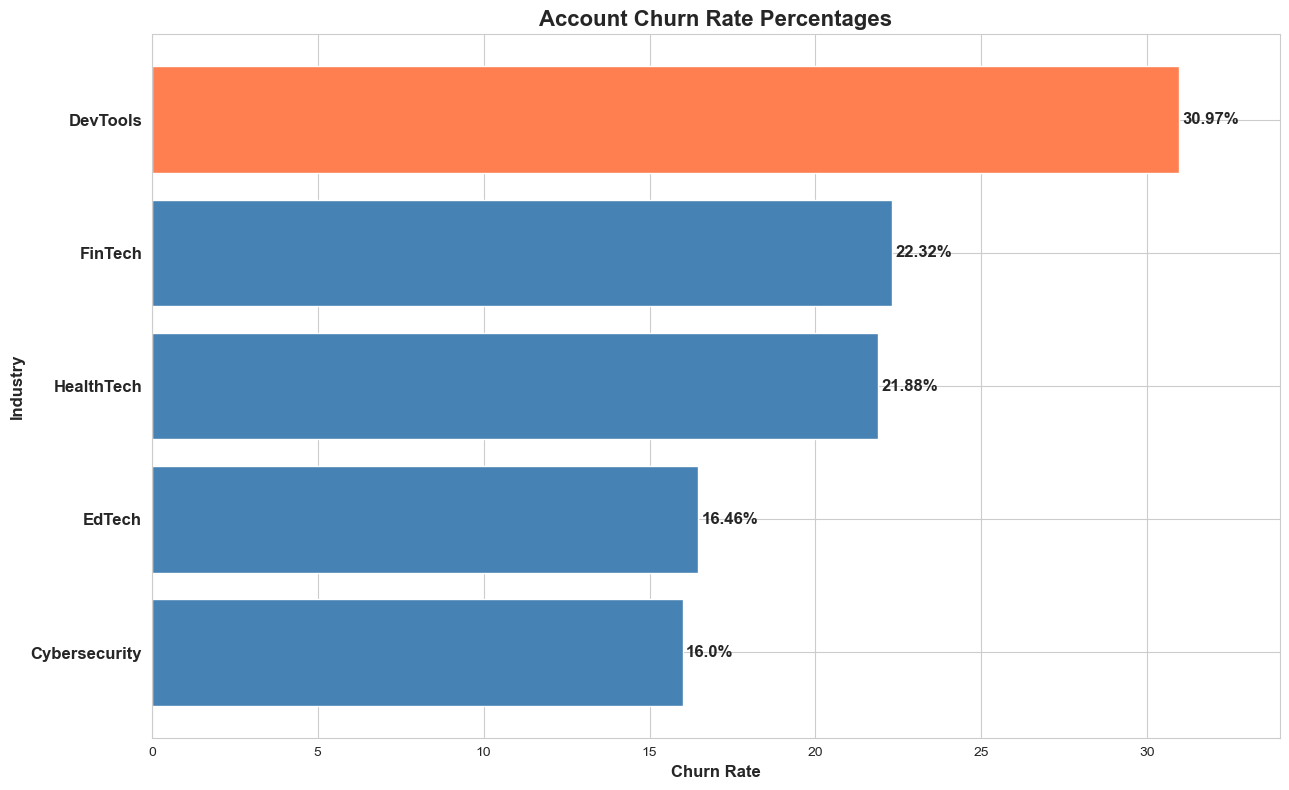

In [552]:
#create a horizontal bar chart
fig, ax =  plt.subplots(figsize = (13,8))

#make devtools a different color since it has highest churn rate 
colors = ['coral' if (i == 'DevTools') else 'steelblue' for i in account_churn_by_industry.index]

#making graph clearer 
ax.barh(account_churn_by_industry.index,account_churn_by_industry['churn rate'], color = colors)
ax.set_title('Account Churn Rate Percentages', fontsize = 16,fontweight = 'bold')
ax.set_xlim((0,34))
ax.set_xlabel('Churn Rate', fontsize = 12,fontweight = 'bold')
ax.set_ylabel('Industry', fontsize = 12, fontweight = 'bold')

#adding percents to chart 
for i,rate in enumerate(account_churn_by_industry['churn rate']):
    rate =  round(rate, 4)
    ax.text(rate +.1, i, f'{rate}%', verticalalignment = 'center', fontsize = 12, fontweight = 'bold')

#making labels more visible
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_fontsize(12)

plt.tight_layout()
plt.show()

In [553]:
#get the most common reason code and group with account since one account can  have multiple subscriptions and hence multiple reason codes
churn_reason = churn.groupby('account_id')['reason_code'].agg(lambda x: x.mode()[0]).reset_index()
churn_reason.shape

(352, 2)

In [554]:
churn_reason.head()

,account_id,reason_code
0,A-00bed1,unknown
1,A-016043,competitor
2,A-029f69,competitor
3,A-02cd81,pricing
4,A-02fac6,support


In [555]:
acc_churn = account[account['churn_flag'] == True]

accounts_churns = pd.merge(acc_churn, churn_reason[['account_id', 'reason_code']],on='account_id', how='left')
accounts_churns['reason_code'] = accounts_churns['reason_code'].fillna('no recorded reason')
accounts_churns.head()

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag,reason_code
0,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True,no recorded reason
1,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True,budget
2,A-7dacce,Company_8,Cybersecurity,CA,2024-09-10,event,Enterprise,12,False,True,budget
3,A-10b8da,Company_9,DevTools,US,2023-05-08,partner,Enterprise,14,False,True,no recorded reason
4,A-592832,Company_10,Cybersecurity,US,2024-09-25,organic,Basic,18,False,True,support


In [556]:
accounts_churns.shape

(110, 11)

In [557]:
industry_reason = accounts_churns.groupby(['industry','reason_code']).size()
industry_reason

industry       reason_code       
Cybersecurity  budget                 5
               competitor             1
               features               1
               no recorded reason     5
               pricing                2
               support                2
DevTools       budget                 8
               competitor             4
               features               3
               no recorded reason     7
               pricing                7
               support                5
               unknown                1
EdTech         budget                 1
               competitor             1
               features               4
               no recorded reason     3
               pricing                1
               support                3
FinTech        budget                 5
               competitor             2
               features               4
               no recorded reason    12
               support                1
      

In [558]:
industry_reason_wide = industry_reason.unstack(level = 'reason_code')
industry_reason_wide.shape

(5, 7)

In [559]:
print(accounts_churns['reason_code'].isna().sum())
print(accounts_churns.shape)

0
(110, 11)


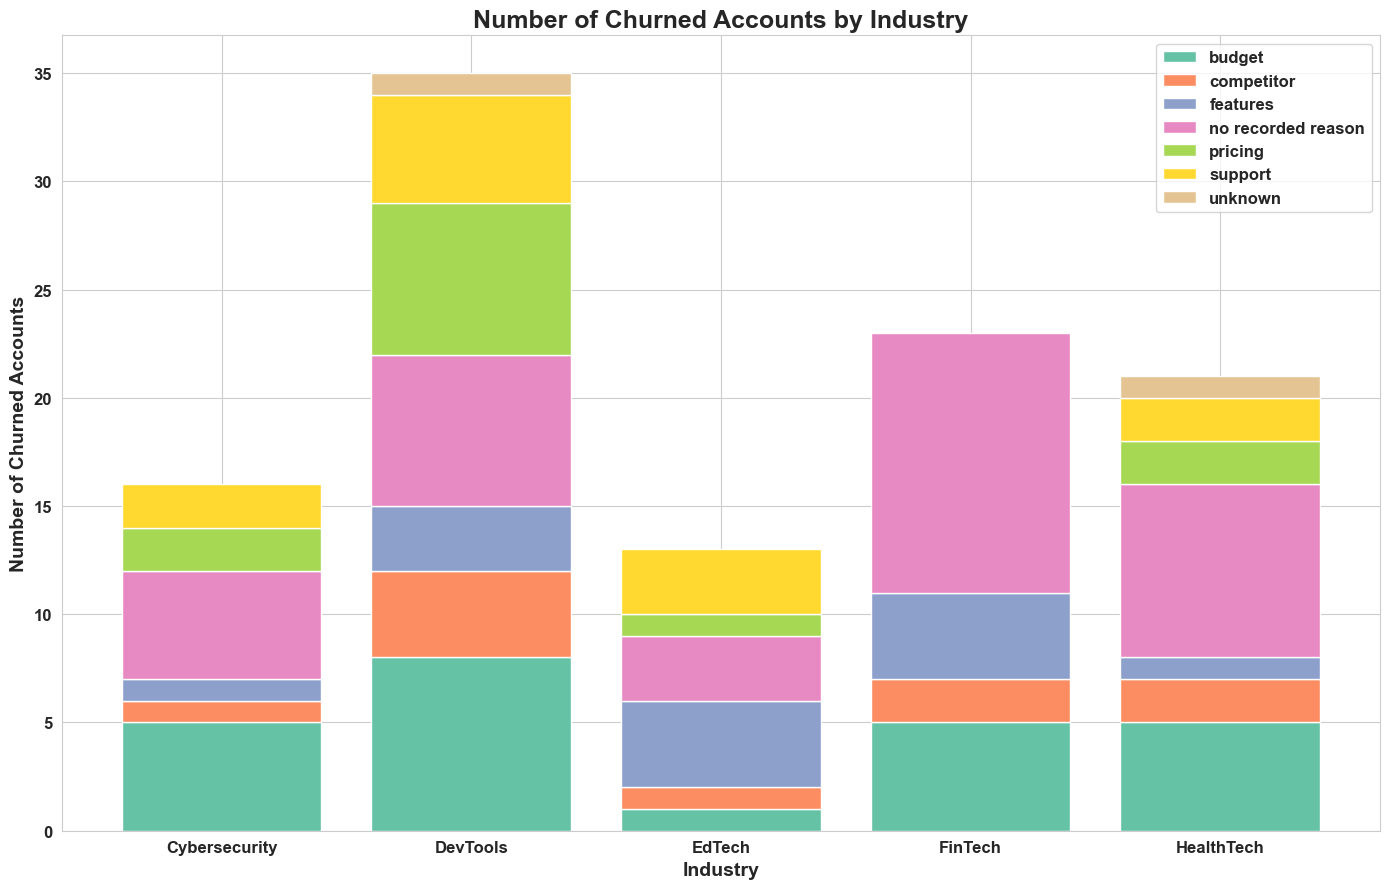

In [560]:
fig, ax = plt.subplots(figsize =(14,9))

bottom = np.zeros(len(industry_reason_wide))

colors = sns.color_palette('Set2',n_colors=7)

for i, reason in enumerate(industry_reason_wide.columns):
    ax.bar(industry_reason_wide.index, 
           industry_reason_wide[reason],
           bottom = bottom,
           color= colors[i],
           label = reason)
    bottom += industry_reason_wide[reason].values

ax.set_xlabel('Industry', fontsize = 14, fontweight = 'bold')
ax.set_ylabel('Number of Churned Accounts', fontsize = 14, fontweight = 'bold')
ax.set_title('Number of Churned Accounts by Industry', fontsize = 18, fontweight = 'bold')

for label in ax.get_xticklabels():
    label.set_fontweight('bold')
    label.set_fontsize(12)

for label in ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_fontsize(12)

ax.legend(loc = 'upper right', prop={'weight':'bold','size':12})

    
plt.tight_layout()
plt.show()

In [561]:
#joining subs and account tables (adding 'industry' column to the subs table)
subs_account = pd.merge(subs,account[['account_id','industry']],on='account_id', how='left')
subs_account.head()

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag,is_active,industry
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True,False,DevTools
1,S-0f6f44,A-9b9fe9,2024-06-11,NaT,Pro,17,833,9996,False,False,False,False,monthly,True,True,EdTech
2,S-51c0d1,A-659280,2024-11-25,NaT,Enterprise,62,0,0,True,True,False,False,annual,False,True,FinTech
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True,False,Cybersecurity
4,S-cff5a2,A-ba6516,2024-01-10,NaT,Enterprise,27,5373,64476,False,False,False,False,monthly,True,True,FinTech


In [562]:
#grouping the 'subs_account' dataset by industry and adding rate and count of churned subscriptions(not accounts)
churn_by_industry = subs_account.groupby('industry')['churn_flag'].agg(total='count', churned = 'sum')
churn_by_industry['rate'] = ((churn_by_industry['churned']/churn_by_industry['total']).round(4))*100
print(churn_by_industry)

               total  churned   rate
industry                            
Cybersecurity   1008      103  10.22
DevTools        1158      125  10.79
EdTech           785       66   8.41
FinTech         1100       96   8.73
HealthTech       949       96  10.12


In [563]:
subs_acc_churn = pd.merge(subs_account,churn_reason[['account_id','reason_code']],on='account_id', how='left')
subs_acc_churn.head()

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag,is_active,industry,reason_code
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True,False,DevTools,NaN
1,S-0f6f44,A-9b9fe9,2024-06-11,NaT,Pro,17,833,9996,False,False,False,False,monthly,True,True,EdTech,features
2,S-51c0d1,A-659280,2024-11-25,NaT,Enterprise,62,0,0,True,True,False,False,annual,False,True,FinTech,features
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True,False,Cybersecurity,budget
4,S-cff5a2,A-ba6516,2024-01-10,NaT,Enterprise,27,5373,64476,False,False,False,False,monthly,True,True,FinTech,budget


In [564]:
churn_only = subs_acc_churn[subs_acc_churn['churn_flag'] == True]

industry_reason = churn_only.groupby(['industry','reason_code']).size()
industry_reason

industry       reason_code
Cybersecurity  budget         19
               competitor     11
               features       14
               pricing         2
               support         8
               unknown        14
DevTools       budget         24
               competitor     13
               features       13
               pricing        15
               support        19
               unknown         9
EdTech         budget         15
               competitor      3
               features       10
               pricing         7
               support         7
               unknown         4
FinTech        budget         26
               competitor     13
               features        7
               pricing         7
               support        15
               unknown        12
HealthTech     budget         15
               competitor     21
               features       11
               pricing         9
               support         7
               u

In [565]:
#joins the 'churn_reason' and 'account' datasets (adds industry to account churn reason) 
subs_acc_churn = pd.merge(churn_reason,account[['account_id','industry']], on='account_id', how='left')
subs_acc_churn.shape

(352, 3)

In [566]:
subs_acc_churn.head()

,account_id,reason_code,industry
0,A-00bed1,unknown,Cybersecurity
1,A-016043,competitor,EdTech
2,A-029f69,competitor,Cybersecurity
3,A-02cd81,pricing,HealthTech
4,A-02fac6,support,FinTech


In [567]:
#group by industry and reason_code and get the size of each group
industry_reason = subs_acc_churn.groupby(['industry','reason_code']).size()
industry_reason

industry       reason_code
Cybersecurity  budget         18
               competitor     14
               features       12
               pricing         9
               support         8
               unknown        11
DevTools       budget         22
               competitor     16
               features       12
               pricing        13
               support        14
               unknown         6
EdTech         budget         10
               competitor      9
               features       16
               pricing         9
               support         7
               unknown         6
FinTech        budget         20
               competitor     12
               features       11
               pricing         8
               support        14
               unknown        11
HealthTech     budget         17
               competitor     15
               features       13
               pricing        11
               support         7
               u

In [568]:
industry_reason_wide = industry_reason.unstack(level = 'reason_code')
industry_reason_wide.shape

(5, 6)

In [569]:
industry_reason_wide.head()

reason_code,budget,competitor,features,pricing,support,unknown
industry,,,,,,
Cybersecurity,18,14,12,9,8,11
DevTools,22,16,12,13,14,6
EdTech,10,9,16,9,7,6
FinTech,20,12,11,8,14,11
HealthTech,17,15,13,11,7,1
